### DATA 201 Week 3 Assignment - Robert Gravatt

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the CSV file into a pandas DataFrame
df = pd.read_csv("housing.csv")


### Part I -- Visualization

#### A. Scatterplots and Aesthetics

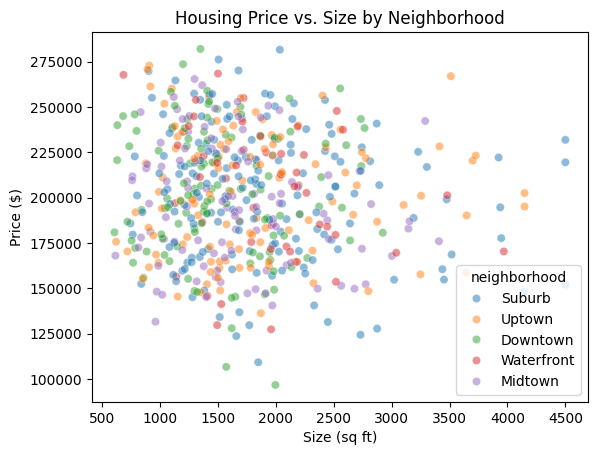

In [15]:


# 1. & 2. Scatterplot of size vs price, colored by neighborhood
# 3. Use transparency (alpha) to reduce overplotting
sns.scatterplot(data=df, x="size", y="price", hue="neighborhood", alpha=0.5)


plt.title("Housing Price vs. Size by Neighborhood")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price ($)")
plt.show()

Seaborn vs Matplotlib: Seaborn automatically handles grouping the data by category (hue="neighborhood") and automatically generates the legend for you. Matplotlib requires you to do this manually with loops.

Transparency (alpha): It is useful here because housing datasets often have dense clusters of data; transparency allows you to see the density of overlapping points rather than just a solid blob of color.

#### B. Small Multiples (Faceting)

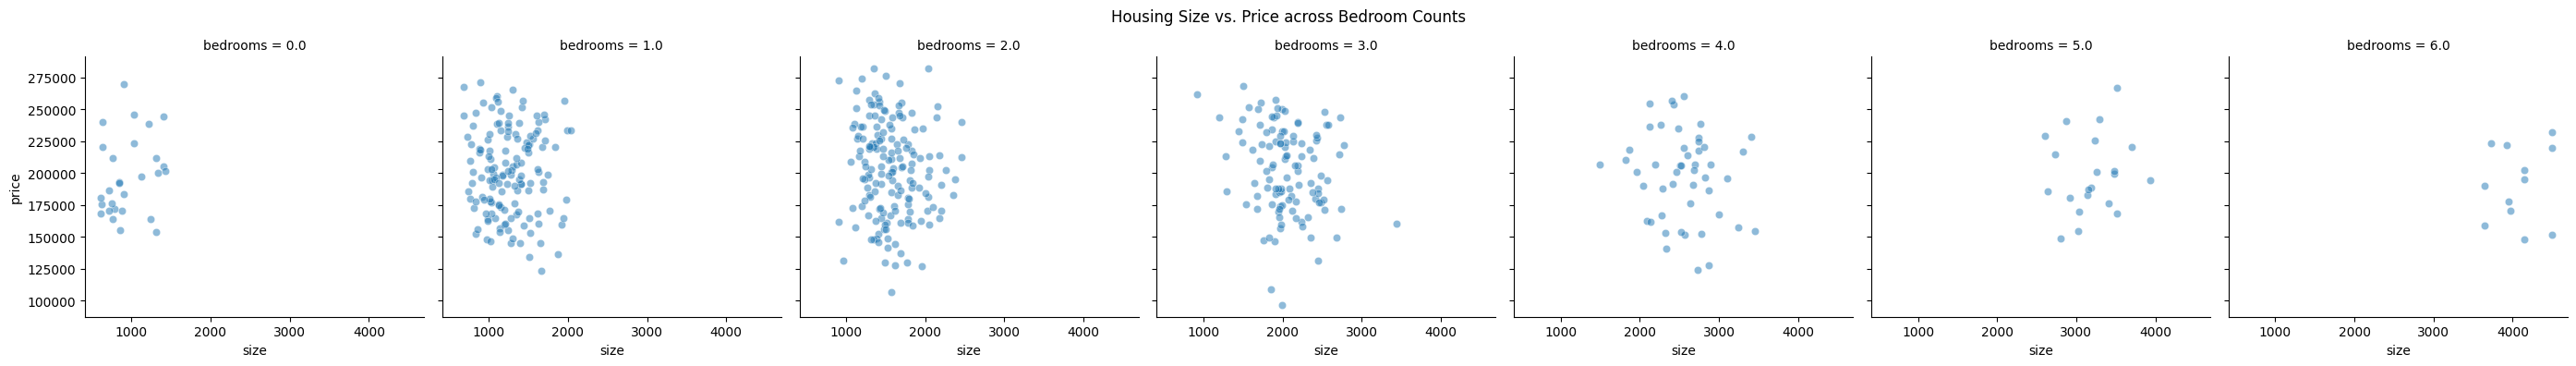

In [16]:
# Create the grid separated by 'bedrooms'
g = sns.FacetGrid(df, col="bedrooms", height=4)

# Map the scatterplot to the grid
g.map(sns.scatterplot, "size", "price", alpha=0.5)

# Add an overall title (adjusting the top so it doesn't overlap)
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle("Housing Size vs. Price across Bedroom Counts")
plt.show()

Tiny little faceted plots.

#### C. Distribution and Categorical Plots

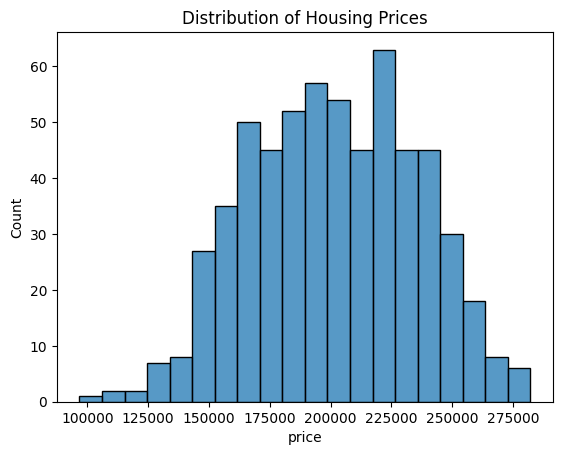

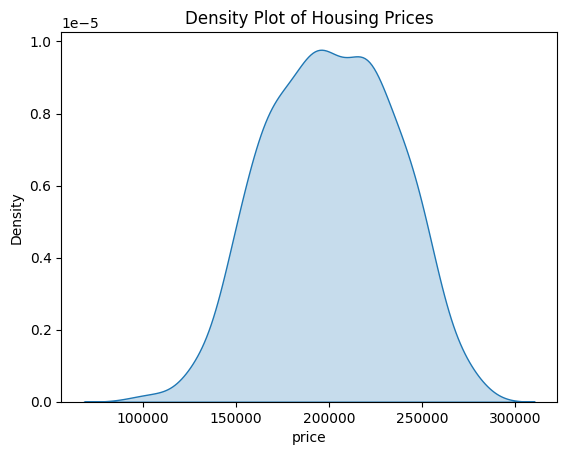

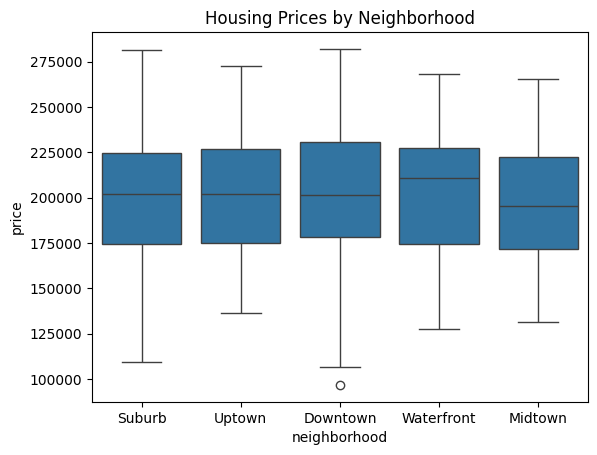

In [17]:
# 1. Histogram of price
sns.histplot(data=df, x="price", bins=20)
plt.title("Distribution of Housing Prices")
plt.show()

# 2. Density plot of price
sns.kdeplot(data=df, x="price", fill=True)
plt.title("Density Plot of Housing Prices")
plt.show()

# 3. Boxplot of price by neighborhood
sns.boxplot(data=df, x="neighborhood", y="price")
plt.title("Housing Prices by Neighborhood")
plt.show()

### Part II — Linear Regression for Inference

#### A. Multiple Regression

In [18]:
import statsmodels.formula.api as smf

# 1. Fit the equivalent model using statsmodels
# Notice the formula is exactly 'price ~ size + bedrooms + neighborhood'
model = smf.ols('price ~ size + bedrooms + neighborhood', data=df).fit()

# 2. Report Coefficient estimates, Standard errors, and R²
# The summary() function produces an output very similar to R's summary(model)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.190
Time:                        01:26:04   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

1. Interpret the coefficient on size, explicitly stating what is being held constant.

For every one-unit (e.g., one square foot) increase in size, the estimated price of the house decreases by $10.93, holding the number of bedrooms and the neighborhood constant.
(Note: It is somewhat unusual for house price to decrease as size increases, but that is exactly what your specific dataset's coefficient of -10.9345 indicates!)

2. Is size statistically significant? How do you know?

Yes, size is statistically significant because its p-value is 0.010, which is less than the standard alpha level of 0.05. This indicates that the relationship between size and price is unlikely to be due to random chance.

3. What does R² tell us in this context?

The R² value of 0.017 tells us that only 1.7% of the variance in housing prices is explained by the combination of the home's size, number of bedrooms, and neighborhood. This suggests that the model explains very little of the actual variation in prices.

### Part III — Prediction Workflow

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 0. Clean the data (scikit-learn cannot handle NaNs natively)
df_clean = df.dropna(subset=['price', 'size', 'bedrooms', 'neighborhood'])

# scikit-learn requires categorical data to be converted to numbers first
X = pd.get_dummies(df_clean[['size', 'bedrooms', 'neighborhood']], drop_first=True)
y = df_clean['price']

# 1. Split the data (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit linear regression using scikit-learn
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

# 3. Compute predictions on the test set
y_pred = model_sk.predict(X_test)

# Compute RMSE and R-squared on the test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R-squared:", r2)

Test RMSE: 37867.669137429715
Test R-squared: -0.050280577121272874


Why does scikit-learn not report p-values?

scikit-learn is a machine learning library built purely for predictive accuracy, not statistical inference. It is designed to evaluate how well a model predicts new, unseen data, rather than checking if individual variables are statistically significant.

Which workflow would you use for Explanation?

You would use statsmodels (or R's lm()) because it provides the detailed statistical summaries (p-values, standard errors, confidence intervals) necessary to explain the relationships between variables.

Which workflow would you use for Prediction?

You would use scikit-learn because it provides the tools (train/test splits, cross-validation, metrics) to build models that generalize well to new data.

Why are these different goals?

Explanation focuses on understanding why something happens and isolating the effect of specific variables (e.g., determining exactly how much value a bedroom adds to a house). Prediction focuses purely on making the most accurate guess for a new observation, even if the model acts as a "black box" where individual relationships are difficult to interpret.

### Part IV -- Integrated Thinking

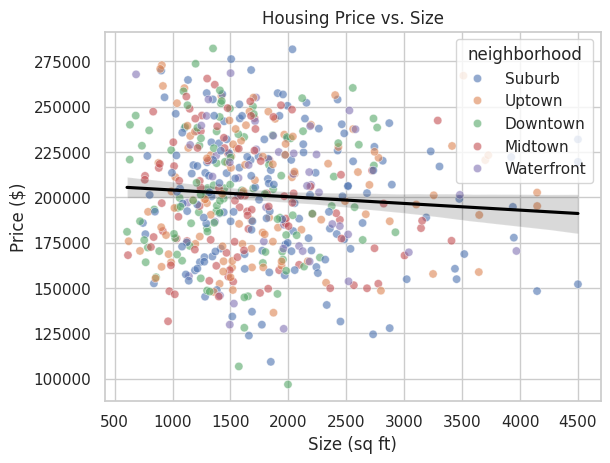

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Scatterplot colored by neighborhood
sns.scatterplot(data=df_clean, x="size", y="price", hue="neighborhood", alpha=0.6)

# 2. Single overall regression line
sns.regplot(data=df_clean, x="size", y="price", scatter=False, color="black")

# 3. Minimal professional formatting (Title and Labels)
plt.title("Housing Price vs. Size")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price ($)")

plt.show()

The regression model perfectly matches what I visually observed in the scatterplot. When looking at the graph, the data points are widely scattered across all neighborhoods without forming a tight, upward-sloping pattern. The single, nearly flat regression line visually confirms the statistical finding that an increase in a home's size does not reliably predict an increase in price for this specific dataset. Because the points do not tightly hug the trend line, the visualization helped me easily anticipate the model's exceptionally low R² value of 0.017. Ultimately, the visual lack of a strong linear relationship provided immediate evidence that the subsequent linear regression model would have poor predictive power.